In [1]:
import coffea
print(coffea.__version__)  # confirm 0.7.x

import numpy as np
from coffea import processor, hist
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import awkward as ak
NanoAODSchema.warn_missing_crossrefs = False

0.7.26


/usr/local/lib/python3.10/site-packages/coffea/util.py:154: FutureWarning: In coffea version v2023.3.0 (target date: 31 Mar 2023), this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
ImportError: coffea.hist is deprecated
  warnings.warn(message, FutureWarning)


In [9]:
class DimuonJetProcessor(processor.ProcessorABC):
    def __init__(self):
        # Define histograms using coffea 0.7.x hist API
        dataset_axis = hist.Cat("dataset", "Dataset")
        
        self._accumulator = processor.dict_accumulator({
            # Dimuon (Z) histograms
            "Z_mass": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("mass", r"$m_{\mu\mu}$ [GeV]", 120, 60, 120),
            ),
            "Z_pt": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("pt", r"$p_T^{\mu\mu}$ [GeV]", 100, 0, 500),
            ),
            "Z_eta": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("eta", r"$\eta_{\mu\mu}$", 60, -6, 6),
            ),
            # Individual muon histograms
            "mu_pt": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("pt", r"$p_T^\mu$ [GeV]", 100, 0, 500),
            ),
            "mu_eta": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("eta", r"$\eta^\mu$", 60, -3, 3),
            ),
            "mu_phi": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("phi", r"$\phi^\mu$", 64, -np.pi, np.pi),
            ),
            # Charge-separated muon pT
            "mu_pt_pos": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("pt", r"$p_T^{\mu^+}$ [GeV]", 100, 0, 500),
            ),
            "mu_pt_neg": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("pt", r"$p_T^{\mu^-}$ [GeV]", 100, 0, 500),
            ),
            # Leading jet histograms
            "jet_pt": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("pt", r"$p_T^{jet}$ [GeV]", 100, 0, 500),
            ),
            "jet_eta": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("eta", r"$\eta^{jet}$", 60, -5, 5),
            ),
            # Back-to-back topology
            "dphi_Z_jet": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("dphi", r"$\Delta\phi(Z, jet)$", 64, 0, np.pi),
            ),
            "Z_jet_pt_balance": hist.Hist(
                "Events",
                dataset_axis,
                hist.Bin("balance", r"$p_T^{jet} / p_T^{Z}$", 60, 0, 2),
            ),
            # Cutflow counter
            "cutflow": processor.defaultdict_accumulator(int),
        })

    @property
    def accumulator(self):
        return self._accumulator

    def process(self, events):
        output = self.accumulator.identity()
        dataset = events.metadata["dataset"]

        # ── Muon selection ──────────────────────────────────────────
        muons = events.Muon
        tight_muons = muons[
            (muons.pt > 20)
            & (np.abs(muons.eta) < 2.4)
            & (muons.tightId)
            & (muons.pfRelIso04_all < 0.15)
            & (np.abs(muons.dz) < 0.5) ## dz < 0.2 cm to prevent pileup
            & (np.abs(muons.dxy) < 0.2)
            & (muons.pfIsoId > 3)
        ]

        # Require exactly 2 opposite-sign tight muons
        os_mask = (
            (ak.num(tight_muons) == 2)
            & (ak.sum(tight_muons.charge, axis=1) == 0)
        )
        output["cutflow"]["two OS muons"] += ak.sum(os_mask)

        sel_events = events[os_mask]
        sel_muons  = tight_muons[os_mask]

        # ── Build Z candidate ────────────────────────────────────────
        mu1 = sel_muons[:, 0]
        mu2 = sel_muons[:, 1]

        Z = mu1 + mu2   # 4-vector sum via LorentzVector behaviour

        Z_mass_mask = (Z.mass > 70) & (Z.mass < 110)
        output["cutflow"]["Z mass window"] += ak.sum(Z_mass_mask)

        mu1   = mu1[Z_mass_mask]
        mu2   = mu2[Z_mass_mask]
        Z     = Z[Z_mass_mask]
        sel_events = sel_events[Z_mass_mask]
        # Z pT cut — only applied after mass window to ensure a valid Z candidate exists
        Z_pt_mask  = Z.pt > 90
        output["cutflow"]["Z pt cut"] += ak.sum(Z_pt_mask)
        mu1        = mu1[Z_pt_mask]
        mu2        = mu2[Z_pt_mask]
        Z          = Z[Z_pt_mask]
        sel_events = sel_events[Z_pt_mask]
        # ── Jet selection ────────────────────────────────────────────
        jets = sel_events.FatJet
        good_jets = jets[
            (jets.pt > 170)
            & (np.abs(jets.eta) < 2.4)
            & (jets.jetId >= 2)   # tight jet ID
        ]

        # Remove jets overlapping with selected muons (dR < 0.4)
        # Remove jets overlapping with selected muons (dR < 0.4)
        # Build lightweight coordinate-only arrays to avoid record key mismatch
        mu1_eta = ak.broadcast_arrays(mu1.eta[:, np.newaxis], good_jets.eta)[0]
        mu1_phi = ak.broadcast_arrays(mu1.phi[:, np.newaxis], good_jets.phi)[0]
        mu2_eta = ak.broadcast_arrays(mu2.eta[:, np.newaxis], good_jets.eta)[0]
        mu2_phi = ak.broadcast_arrays(mu2.phi[:, np.newaxis], good_jets.phi)[0]
        
        deta1 = good_jets.eta - mu1_eta
        dphi1 = good_jets.phi - mu1_phi
        dphi1 = (dphi1 + np.pi) % (2 * np.pi) - np.pi   # wrap to [-π, π]
        dR1   = np.sqrt(deta1**2 + dphi1**2)
        
        deta2 = good_jets.eta - mu2_eta
        dphi2 = good_jets.phi - mu2_phi
        dphi2 = (dphi2 + np.pi) % (2 * np.pi) - np.pi
        dR2   = np.sqrt(deta2**2 + dphi2**2)
        
        good_jets = good_jets[(dR1 > 0.4) & (dR2 > 0.4)]

        # # Require at least one jet back-to-back with Z (|Δφ| > 2.7 rad)
        # lead_jet = ak.pad_none(good_jets, 1)[:, 0]
        # has_jet  = ~ak.is_none(lead_jet)

        # dphi = np.abs(Z[has_jet].delta_phi(lead_jet[has_jet]))
        # btb_mask_local = dphi > 1.57

        # # Apply has_jet then back-to-back masks
        # Z_j    = Z[has_jet][btb_mask_local]
        # mu1_j  = mu1[has_jet][btb_mask_local]
        # mu2_j  = mu2[has_jet][btb_mask_local]
        # jet_j  = lead_jet[has_jet][btb_mask_local]
        # dphi_j = dphi[btb_mask_local]

        # Back-to-back cut
        lead_jet = ak.pad_none(good_jets, 1)[:, 0]
        has_jet  = ~ak.is_none(lead_jet)
        
        dphi = np.abs(Z[has_jet].delta_phi(lead_jet[has_jet]))
        btb_mask_local = dphi > 2.7
        
        # Apply has_jet then back-to-back masks
        Z_j    = Z[has_jet][btb_mask_local]
        mu1_j  = mu1[has_jet][btb_mask_local]
        mu2_j  = mu2[has_jet][btb_mask_local]
        jet_j  = lead_jet[has_jet][btb_mask_local]
        dphi_j = dphi[btb_mask_local]
        
        output["cutflow"]["back-to-back jet"] += ak.sum(btb_mask_local)
        
        # ── ADD: pt asymmetry cut ──────────────────────────────────────────
        pt_asym = np.abs(Z_j.pt - jet_j.pt) / (Z_j.pt + jet_j.pt)
        pt_asym_mask = pt_asym < 0.3
        output["cutflow"]["pt asymmetry cut"] += ak.sum(pt_asym_mask)
        
        Z_j    = Z_j[pt_asym_mask]
        mu1_j  = mu1_j[pt_asym_mask]
        mu2_j  = mu2_j[pt_asym_mask]
        jet_j  = jet_j[pt_asym_mask]
        dphi_j = dphi_j[pt_asym_mask]

        output["cutflow"]["back-to-back jet"] += ak.sum(btb_mask_local)

        # ── Fill histograms ──────────────────────────────────────────
        # Z candidate
        output["Z_mass"].fill(dataset=dataset, mass=ak.to_numpy(Z_j.mass))
        output["Z_pt"].fill(dataset=dataset,   pt=ak.to_numpy(Z_j.pt))
        output["Z_eta"].fill(dataset=dataset,  eta=ak.to_numpy(Z_j.eta))


        # Individual muons (flatten both into one array for inclusive plots)
        all_mu_pt  = ak.to_numpy(ak.concatenate([mu1_j.pt,  mu2_j.pt]))
        all_mu_eta = ak.to_numpy(ak.concatenate([mu1_j.eta, mu2_j.eta]))
        all_mu_phi = ak.to_numpy(ak.concatenate([mu1_j.phi, mu2_j.phi]))
        output["mu_pt"].fill(dataset=dataset,  pt=all_mu_pt)
        output["mu_eta"].fill(dataset=dataset, eta=all_mu_eta)
        output["mu_phi"].fill(dataset=dataset, phi=all_mu_phi)
        
        # Charge-separated pT: identify which of mu1/mu2 is positive/negative
        # mu1 and mu2 are already guaranteed OS, so one has charge +1 and one -1
        mu_pos_pt = ak.where(mu1_j.charge > 0, mu1_j.pt, mu2_j.pt)
        mu_neg_pt = ak.where(mu1_j.charge < 0, mu1_j.pt, mu2_j.pt)
        output["mu_pt_pos"].fill(dataset=dataset, pt=ak.to_numpy(mu_pos_pt))
        output["mu_pt_neg"].fill(dataset=dataset, pt=ak.to_numpy(mu_neg_pt))

        # Leading jet
        output["jet_pt"].fill(dataset=dataset,  pt=ak.to_numpy(jet_j.pt))
        output["jet_eta"].fill(dataset=dataset, eta=ak.to_numpy(jet_j.eta))

        # Back-to-back topology
        output["dphi_Z_jet"].fill(dataset=dataset,   dphi=ak.to_numpy(dphi_j))
        output["Z_jet_pt_balance"].fill(
            dataset=dataset,
            balance=ak.to_numpy(jet_j.pt / Z_j.pt),
        )

        return output

    def postprocess(self, accumulator):
        return accumulator

In [10]:
from pathlib import Path

def fileset_from_txt_list(txt_files, max_files=None):
    """
    txt_files : list of paths to txt files
    Each txt file corresponds to one dataset.
    Dataset name is inferred from txt filename.
    """

    fileset = {}
    prependstr = "root://xcache/"

    for txt_path in txt_files:
        txt_path = Path(txt_path)

        # Infer dataset name from txt filename
        name = txt_path.stem  # removes .txt

        # Clean naming logic
        if "SingleMuon" in name:
            dataset_name = "SingleMuon"
        elif "pythia" in name.lower():
            dataset_name = "pythia"
        else:
            dataset_name = name  # fallback: use filename directly

        files = []
        for line in txt_path.read_text().splitlines():
            line = line.strip()
            if (not line) or line.startswith("#"):
                continue
            files.append(prependstr + line)

        if max_files is not None:
            files = files[:max_files]

        fileset[dataset_name] = files

    return fileset

In [11]:
txt_path = ["samples_mc/inclusiveLO_UL16NanoAODv9.txt", "samples/SingleMuon_UL2016.txt"]   # <-- change
fileset = fileset_from_txt_list(txt_path, max_files = None)

In [12]:
from dask.distributed import Client

client = Client("tls://localhost:8786")
client

<Client: 'tls://192.168.202.37:8786' processes=22 threads=22, memory=168.01 GiB>

In [13]:
from coffea import processor
from coffea.nanoevents import NanoAODSchema



# iterative_executor runs locally, file-by-file — ideal for notebooks/debugging
# run = processor.Runner(
#     executor=processor.IterativeExecutor(),
#     schema=NanoAODSchema,
#     chunksize=100_000,   # events per chunk
#     maxchunks=5,      # set e.g. maxchunks=2 to test on a subset
# )

# out = run(
#     fileset,
#     "Events",
#     processor_instance=DimuonJetProcessor(),
# )

# print("Cutflow:", dict(out["cutflow"]))

# Use this cell instead of Cell 4 when you want multi-core processing


run = processor.Runner(
    executor=processor.DaskExecutor(client=client),
    schema=NanoAODSchema,
    chunksize=400_000,
    maxchunks=None,     # set e.g. maxchunks=5 to test first
    skipbadfiles = True
)

out = run(
    fileset,
    "Events",
    processor_instance=DimuonJetProcessor(),
)

# print("Cutflow:", dict(out["cutflow"]))

[########################################] | 100% Completed |  2min 39.7s

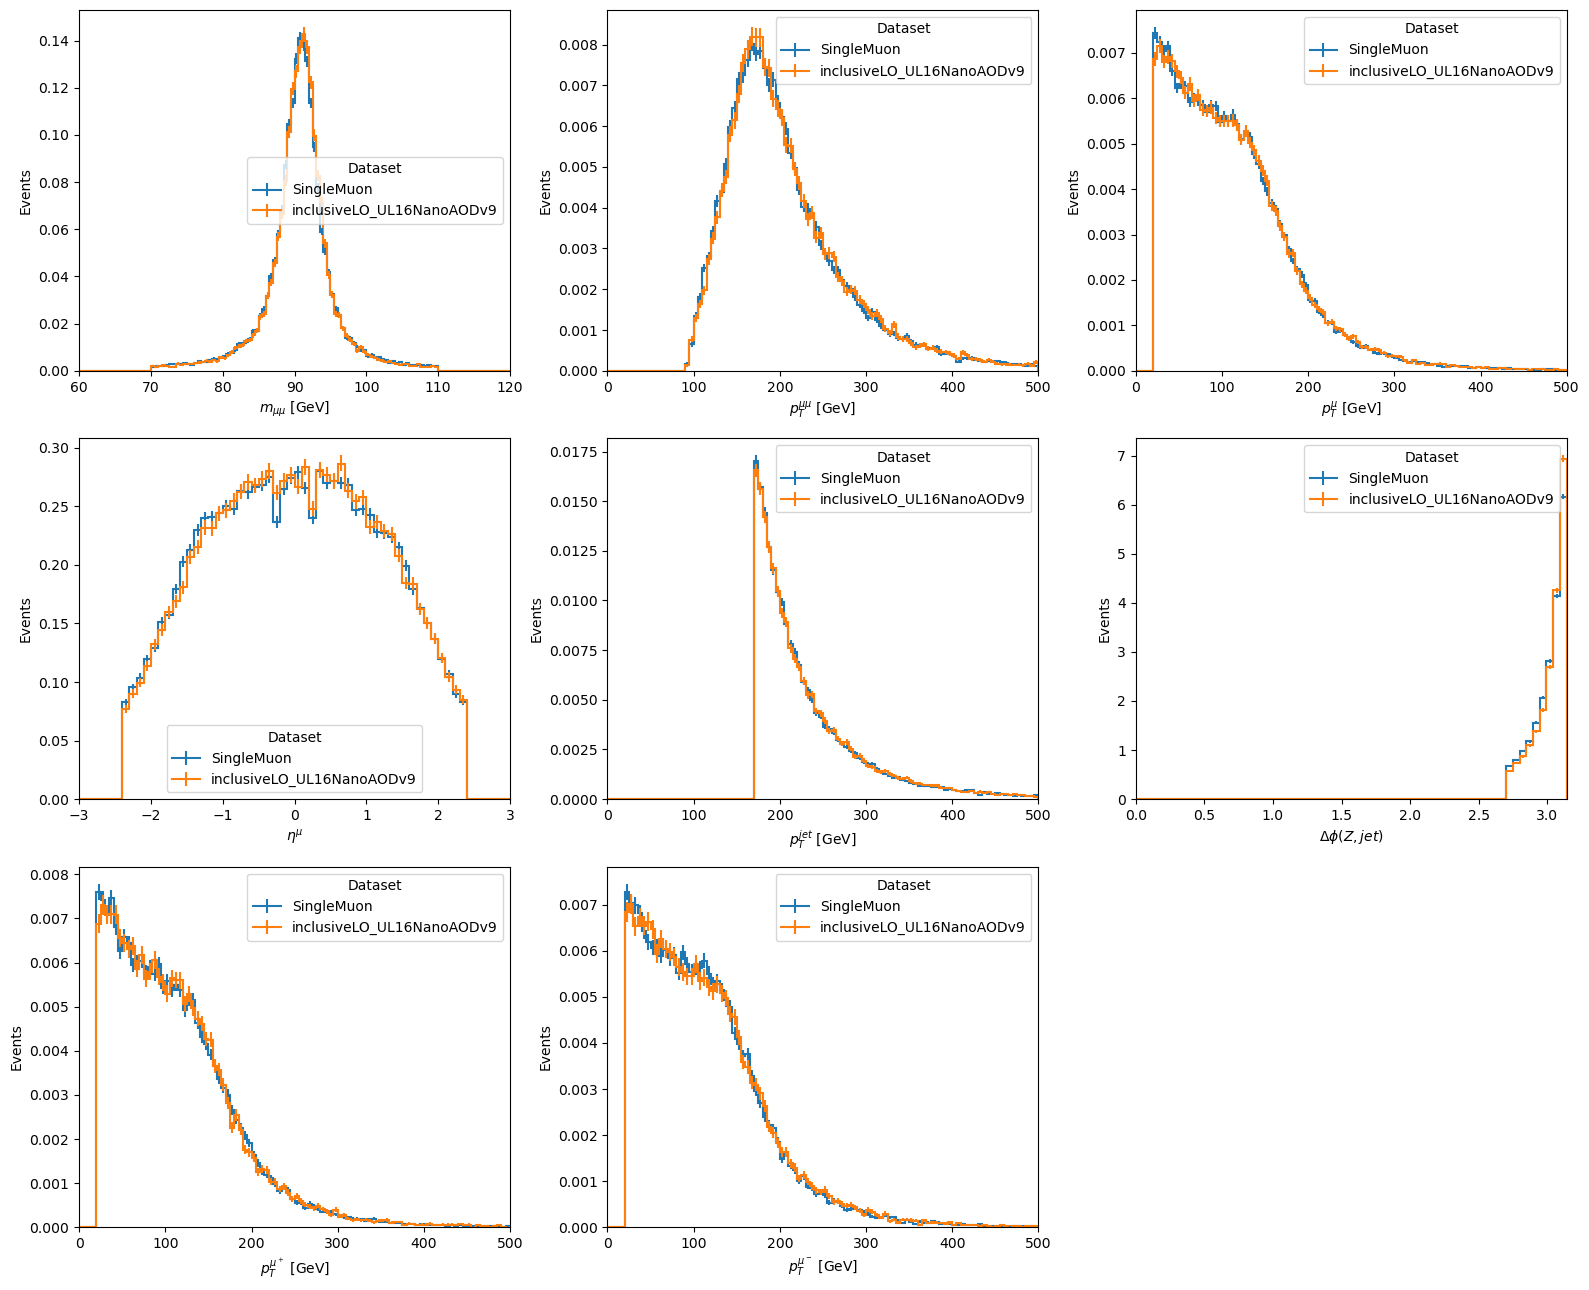

In [15]:
import matplotlib.pyplot as plt
from coffea.hist import plot

fig, axes = plt.subplots(3, 3, figsize=(16, 13))

plot.plot1d(out["Z_mass"],      ax=axes[0, 0], density = True)
plot.plot1d(out["Z_pt"],        ax=axes[0, 1], density = True)
plot.plot1d(out["mu_pt"],       ax=axes[0, 2], density = True)
plot.plot1d(out["mu_eta"],      ax=axes[1, 0], density = True)
plot.plot1d(out["jet_pt"],      ax=axes[1, 1], density = True)
plot.plot1d(out["dphi_Z_jet"],  ax=axes[1, 2], density = True)
plot.plot1d(out["mu_pt_pos"],   ax=axes[2, 0], density = True)
plot.plot1d(out["mu_pt_neg"],   ax=axes[2, 1], density = True)
axes[2, 2].axis("off")  # empty slot

# for ax in axes.flat:
#     ax.set_yscale("log")

plt.tight_layout()
plt.show()